>0 f([0.22723038]) = 0.05163
>1 f([0.18178431]) = 0.03305
>2 f([0.14542744]) = 0.02115
>3 f([0.11634196]) = 0.01354
>4 f([0.09307356]) = 0.00866
>5 f([0.07445885]) = 0.00554
>6 f([0.05956708]) = 0.00355
>7 f([0.04765367]) = 0.00227
>8 f([0.03812293]) = 0.00145
>9 f([0.03049835]) = 0.00093
>10 f([0.02439868]) = 0.00060
>11 f([0.01951894]) = 0.00038
>12 f([0.01561515]) = 0.00024
>13 f([0.01249212]) = 0.00016
>14 f([0.0099937]) = 0.00010
>15 f([0.00799496]) = 0.00006
>16 f([0.00639597]) = 0.00004
>17 f([0.00511677]) = 0.00003
>18 f([0.00409342]) = 0.00002
>19 f([0.00327473]) = 0.00001
>20 f([0.00261979]) = 0.00001
>21 f([0.00209583]) = 0.00000
>22 f([0.00167666]) = 0.00000
>23 f([0.00134133]) = 0.00000
>24 f([0.00107307]) = 0.00000
>25 f([0.00085845]) = 0.00000
>26 f([0.00068676]) = 0.00000
>27 f([0.00054941]) = 0.00000
>28 f([0.00043953]) = 0.00000
>29 f([0.00035162]) = 0.00000


/tmp/ipykernel_13144/3797309213.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('>%d f(%s) = %.5f' % (i, solution, solution_eval))


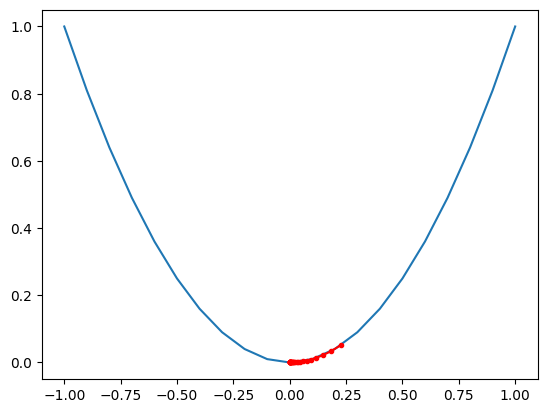

In [4]:
from numpy import asarray # Used to convert normal Python lists into NumPy arrays (needed for vector operations)
from numpy import arange # Used to generate evenly spaced numbers (like range but supports decimals)
from numpy.random import rand # Generated random numbers between 0 and 1
from matplotlib import pyplot # Library used for plotting graphs

# objective functions
def objective(x):
    return x**2.0 # Function we want to minimize -> f(x) = x^2 (a bowl-shaped curve, minimum at x = 0)

# derivative of objective function
def derivative(x):
    return x * 2.0 # Derivative of x^2 is 2x -> tells slope (direction + steepness)

# gradient descent algorithm
def gradient_descent(objective, derivative, bounds, n_iter, step_size):
  solutions, scores = list(), list()
  solution = bounds[:,0] + rand(len(bounds)) * (bounds[:,1] - bounds[:,0])
  # Step-by-step:
  # bounds[:, 0] -> lower bound (e.g., -1)
  # bounds[:, 1] -> upper bound (e.g., 1)
  # rand(...) -> random number between 0 and 1
  # So this picks a random starting point between -1 and 1
  # IMPORTANT: Gradient descent usually starts from a random guess

  #run the gradient descent
  for i in range(n_iter): # Loop runs 'n_iter' times (each loop = one step downhill)
    gradient = derivative(solution)
    # Compute slope at current point
    # If slope is positive -> move left
    # If slope is negative -> move right

    solution = solution - step_size * gradient
    # Core idea of gradient descent:
    # new_x = old_x - (learning_rate * slope)
    # We subtract because we want to move "downhill"
    # step_size controls how big each step is

    solution_eval = objective(solution)
    # Evaluate how good this solution is (calculate f(x))

    solutions.append(solution)
    # Store current x value

    scores.append(solution_eval)
    # Store corresponding function value

    print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
    # Print progress:
    # i -> iteration number
    # solution -> current x
    # solution_eval -> current f(x)

  return[solutions, scores]
  # Return all visited points and their values

# define range for input
bounds = asarray([[-1.0, 1.0]])
# Search space -> x can be between -1 and 1

# define the total iterations
n_iter = 30
# Number of steps gradient descent will take
# More iterations -> better  change to reach minimum

# define the step size
step_size = 0.1
# Learning rate:
# Small -> slow but stable
# Large -> fast but may overshoot

# perform the gradient descent search
solutions, scores = gradient_descent(objective, derivative, bounds, n_iter, step_size)
# Run algorithm and collect all steps taken

# sample input range uniformly at 0.1 increments
inputs = arange(bounds[0,0], bounds[0,1]+0.1, 0.1)
# Creates values like: -1.0, -0.9, ..., 1.0
# Used for plotting the actual function curve

# compute targets
results = objective(inputs)
# Apply f(x) = x^2 to all input values to get curve points

# create a line plot of input vs result
pyplot.plot(inputs,results)
# Plot the actual function curve (parabola)

# plot the solutions found
pyplot.plot(solutions , scores, '.-', color='red')
# Plot the path taken by the gradient descent
# '.' -> points

# show the plot
pyplot.show()
# Display the final graph